# 게스트는 왜 안 남고, 왜 로그인하지 않는가

**작성** 2026-09-03 · **원천** BigQuery GA4 export + `calm_forest_raw` 미러

`02_churn_where.ipynb` 에서 "이탈이 입구에서 일어난다"까지 봤다.
이 노트북은 그다음 질문을 따라간다 — 튜토리얼은 어디서 끊기나, 게스트는 한 번에 얼마나 하나,
그리고 로그인으로 넘어가는 길이 실제로 작동하나.

**결론부터**

- 튜토리얼은 사람을 쫓아내지 않는다. 애초에 들어오는 사람이 26대뿐이다.
- 게스트가 다수(전체의 32%, 로그인 유저는 8%)이고, 한 세션에 행동 6종·3분 하고 떠난다.
- 로그인 넛지는 게스트 77대 중 10대에게만 떴고 **클릭은 0건**이다.

모델은 만들지 않았다.

In [1]:
import warnings
warnings.filterwarnings("ignore", message=".*BigQuery Storage.*")

from calm_ml import bq, report as R
import pandas as pd

R.setup()
pd.set_option("display.max_rows", 40)

# '게임 행동'으로 칠 이벤트의 여집합. 노트북 전체가 이 한 정의를 공유한다.
#  - 자동 수집: first_visit / session_start / page_view / scroll / user_engagement
#  - 게임이 스스로 남기는 기록: session_time / session_summary / weather_day / weather_event
#  - 다른 행동에 딸려 나가는 원장: econ_tx
#  - login: 재방문 시 자동 발화라 플레이 근거가 못 된다(02 노트북에서 확인)
EXCLUDE = """'first_visit','session_start','page_view','scroll','user_engagement',
              'session_time','session_summary','weather_day','weather_event','econ_tx','login'"""
GA4 = "`calm-forest.analytics_547127440.events_*`"

## 1. 튜토리얼은 어디서 끊기나

분모를 정하기 전에 이벤트부터 확인한다.

**`tutorial_complete` 는 정상 작동한다.** [index.html:1930](../index.html) 에서
`tutIdx` 가 `TUT_STEPS.length` 에 닿을 때만 나간다. 즉 **그 시점 배열의 모든 단계를
한 번의 코치 실행에서 끝내야** 한다. 중간 종료(`coach-skip`)로는 절대 안 나간다.

```js
if (TUT_STEPS[tutIdx].key === type) {
  trackEvent('tutorial_step', { step: tutIdx + 1, key: TUT_STEPS[tutIdx].key });
  tutIdx++;
  if (tutIdx >= TUT_STEPS.length) endCoach(true);   // ← 여기서만 complete
  else renderCoach();
}
```

다만 **단계 수가 계속 자라 왔다.**

| 날짜 | 단계 | 커밋 |
|---|---|---|
| 07-27 | 6 | `15d3df9` 온보딩 튜토리얼 추가 |
| **07-29** | **11** | `e5b828c` |
| 08-06 | 14 | `bedae08` 시세·전광판 |
| 08-08 | 15 | `7f2fd99` 도감 신설 |
| 08-23 | 16 | `502417d` 도구바 4칸 |
| **09-01** | **17** | `dc06b48` 조각 미니게임 |

그래서 "완주"의 기준이 시점마다 다르다. 완주율을 기간 통째로 묶으면 서로 다른 것을 더하게 된다.
**17단계판을 완주한 기기는 0대**다 — 다만 09-02 배포라 관측이 하루뿐이라 길이 탓이라고 말할 수 없다.

**`step` 인덱스는 시점 비교에 못 쓴다.** step 2 가 `chop`(15대)이기도 하고 `toolpage`(3대)이기도 하다.
번호가 시점마다 다른 내용을 가리킨다.

그래서 두 가지로 잰다 — 먼저 **단계별 도달 기기 수**(한 판 안에서 어디서 빠지는지),
그다음 **`key` 별 도달**(판이 바뀌어도 비교 가능). 완주 여부에는 기대지 않는다.

In [2]:
tut = bq.read_sql(f"""
WITH tut AS (
  SELECT user_pseudo_id AS device, event_name,
         (SELECT value.int_value FROM UNNEST(event_params) WHERE key='step') AS step,
         (SELECT COALESCE(value.string_value, CAST(value.int_value AS STRING))
          FROM UNNEST(event_params) WHERE key='at') AS skip_at
  FROM {GA4}
  WHERE event_name LIKE 'tutorial%'
)
SELECT device,
       MAX(IF(event_name='tutorial_step', step, NULL))                        AS max_step,
       COUNTIF(event_name='tutorial_complete') > 0                            AS completed,
       COUNTIF(event_name='tutorial_skip' AND skip_at='welcome')  > 0         AS skip_welcome
FROM tut GROUP BY device
""")

s = tut[tut.max_step.notna()]
print(f"튜토리얼 이벤트가 있는 기기 {len(tut)}대 · 단계를 밟은 기기 {len(s)}대")
print(f"welcome 스킵 {int(tut.skip_welcome.sum())}대")
print(f"완료 이벤트를 찍은 기기 {int(tut.completed.sum())}대")

튜토리얼 이벤트가 있는 기기 89대 · 단계를 밟은 기기 26대
welcome 스킵 73대
완료 이벤트를 찍은 기기 6대


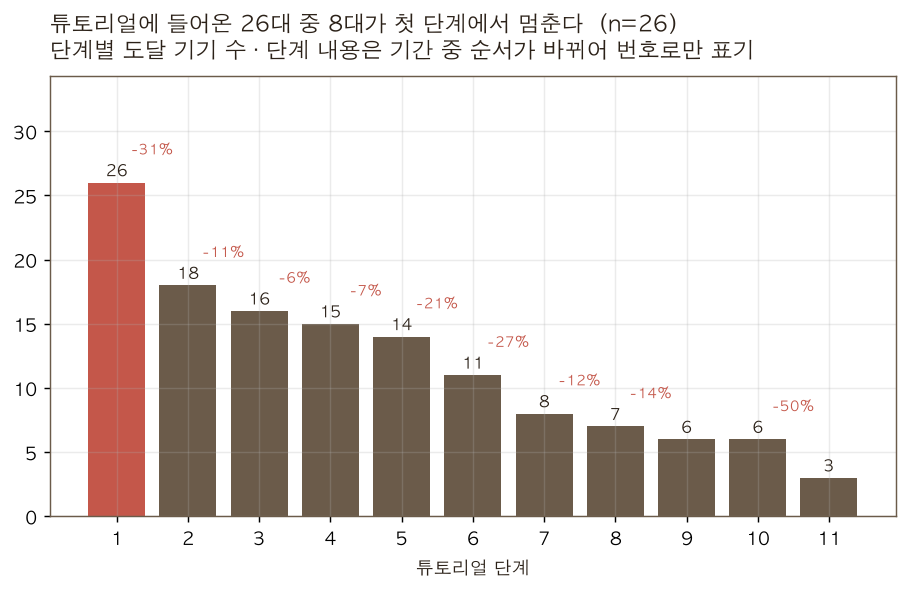

In [3]:
# '몇 단계에서 멈췄나'가 아니라 '몇 단계까지 갔나' — 누적 도달로 세야 퍼널이 된다
steps = list(range(1, int(s.max_step.max()) + 1))
reach = [int((s.max_step >= n).sum()) for n in steps]
n = len(s)

fig, ax = R.new("튜토리얼에 들어온 26대 중 8대가 첫 단계에서 멈춘다", n=n,
                sub="단계별 도달 기기 수 · 단계 내용은 기간 중 순서가 바뀌어 번호로만 표기",
                figsize=(8.4, 4.4))
ax.bar([str(x) for x in steps], reach, color=[R.PALETTE[0]] + [R.MUTED] * (len(steps) - 1))
ax.set_xlabel("튜토리얼 단계")
for i, v in enumerate(reach):
    ax.text(i, v + 0.5, str(v), ha="center", fontsize=9, color=R.INK)
    if i and reach[i-1] - v:
        ax.text(i - 0.5, reach[i-1] + 2.2, f"-{(reach[i-1]-v)/reach[i-1]:.0%}",
                ha="center", fontsize=8, color=R.PALETTE[0])
ax.set_ylim(0, max(reach) * 1.32)
R.show(R.save(fig, ax, "g_tutorial_funnel"))

### 완주자를 날짜로 갈라 보면

`max_step` 은 **기기의 평생 최대값**이라, 완주한 판과 나중에 다시 도전하다 만 판이 섞인다.
날짜로 나누면 전부 맞아떨어진다 — 완주는 그 시점 배열 길이(6 또는 11)에서 일어났다.

In [4]:
byday = bq.read_sql(f"""
WITH e AS (
  SELECT user_pseudo_id AS device, event_name,
         DATE(TIMESTAMP_MICROS(event_timestamp), 'Asia/Seoul') AS d,
         (SELECT value.int_value FROM UNNEST(event_params) WHERE key='step') AS step
  FROM {GA4}
  WHERE event_name IN ('tutorial_step','tutorial_start','tutorial_complete')
),
c AS (SELECT DISTINCT device FROM e WHERE event_name='tutorial_complete')
SELECT e.device, e.d,
       COUNTIF(e.event_name='tutorial_start')    AS starts,
       COUNTIF(e.event_name='tutorial_complete') AS completes,
       MAX(IF(e.event_name='tutorial_step', e.step, NULL)) AS max_step_that_day
FROM e JOIN c USING (device)
GROUP BY 1, 2 ORDER BY device, d
""")
byday["device"] = byday.device.str[-4:]      # 표가 넘치지 않게 뒤 4자리만
print(byday.to_string(index=False))

device          d  starts  completes  max_step_that_day
  3844 2026-07-29       2          1                  6
  3844 2026-07-31       1          0                 10
  2325 2026-07-29       6          1                 10
  4596 2026-08-03       1          1                 11
  8383 2026-08-03       1          0                  7
  8383 2026-08-04       1          1                 11
  4289 2026-07-28       5          2                  6
  4289 2026-08-01       1          0                  1
  4289 2026-08-03       1          0                  1
  3569 2026-07-28       1          1                  6
  3569 2026-07-30       1          0                  5


### 읽은 것

완주 6건은 전부 **6단계판(07-28~29)** 또는 **11단계판(08-03~04)** 에서 나왔다.
그 뒤 다시 코치를 돌렸다 중간에 만 기록이 같은 기기에 겹쳐 있어서, 평생 최대값만 보면
"6단계 완주자가 10단계에 있다"처럼 보였던 것이다.

**덤으로 나온 것** — `tutorial_start` 가 한 기기에서 하루에 **6번**까지 찍힌다.
완주를 하루에 2번 한 기기도 있다. 코치를 반복해서 돌리고 있다는 뜻이고,
2~3절에서 볼 환영 모달 반복과 같은 뿌리로 보인다.

### 읽은 것

1단계 → 2단계에서 31%(8대)가 빠진다. 그 뒤로는 6~11%씩 완만하다가 6·7단계에서 다시 21%·27%.
5단계 이상 14대(54%), 11단계 3대(12%).

분모를 어디로 잡느냐로 답이 갈린다.

| 분모 | 끝까지 | 중간 이탈 |
|---|---|---|
| 단계를 밟은 26대 | 3대 | **88%** |
| 튜토리얼 화면을 본 89대 | 3대 | 97% |

**튜토리얼이 사람을 쫓아내는 게 아니다.** 들어온 사람이 26대뿐인 게 문제다.
`welcome` 스킵 73대가 그 세 배다. 다음 절에서 그 73대를 본다.

### 판이 바뀌었으니 키로도 세어 본다

위 퍼널은 **번호** 기준이라 한 판 안에서 어디서 빠지는지는 보여주지만,
판이 6→17단계로 자라는 동안 같은 번호가 다른 내용을 가리켜서 **시점 비교에는 못 쓴다.**
`key` 로 세면 순서가 바뀌어도 "무엇을 했나"는 유지된다.

In [5]:
bykey = bq.read_sql(f"""
SELECT (SELECT value.string_value FROM UNNEST(event_params) WHERE key='key') AS step_key,
       COUNT(DISTINCT user_pseudo_id) AS devices_all,
       COUNT(DISTINCT IF(DATE(TIMESTAMP_MICROS(event_timestamp), 'Asia/Seoul') >= '2026-08-06',
                         user_pseudo_id, NULL))                                AS devices_since_0806,
       MIN(DATE(TIMESTAMP_MICROS(event_timestamp), 'Asia/Seoul'))              AS first_seen,
       MAX(DATE(TIMESTAMP_MICROS(event_timestamp), 'Asia/Seoul'))              AS last_seen
FROM {GA4}
WHERE event_name = 'tutorial_step'
GROUP BY 1 ORDER BY devices_all DESC
""")
print(bykey.to_string(index=False))
print("\ncarve 이벤트:", int(bykey[bykey.step_key == 'carve'].devices_all.sum()), "건")

step_key  devices_all  devices_since_0806 first_seen  last_seen
    move           26                  11 2026-07-28 2026-08-29
    chop           17                   5 2026-07-28 2026-08-29
    till           16                   4 2026-07-28 2026-08-29
    seed           14                   3 2026-07-28 2026-08-29
   water           13                   2 2026-07-28 2026-08-10
 harvest            9                   2 2026-07-29 2026-08-10
   quest            8                   2 2026-07-29 2026-08-10
    fish            5                   0 2026-07-29 2026-08-04
   enter            4                   0 2026-07-29 2026-08-04
    talk            4                   0 2026-07-28 2026-07-29
   build            4                   0 2026-07-29 2026-08-04
toolpage            3                   3 2026-08-23 2026-08-29
    sell            2                   2 2026-08-08 2026-08-10
  market            2                   2 2026-08-08 2026-08-10
    mine            2                   

### 읽은 것 — 12단계 이상이 비어 있는 이유

**계측이나 코드 문제가 아니다.** 17개 키 전부 호출부가 있다.
12번째인 `carve` 도 [game.js:5781](../js/game.js) 에 `ui.act?.('carve')` 가 있다.

이유는 셋이 겹친다.

1. **12단계 자리가 생긴 게 08-06** 이다. 그전에는 배열이 11개뿐이었다.
2. **현재 12번째인 `carve` 는 09-01 에 들어왔다.** 데이터가 09-02 까지라 하루뿐이다 → 0건이 당연하다.
3. **08-06 이후 튜토리얼을 시작한 기기가 11대뿐**이고, `chop` 5대 · `till` 4대로 곧장 빠진다.
   가장 깊이 간 건 `dex` 1대다.

`fish`·`build`·`enter`·`decor` 가 08-06 이후 0건인 것도 같은 이유다.
11단계판에서는 8~11번째였다가 14단계판부터 뒤로 밀렸고, 거기까지 간 사람이 없다.

**"12단계가 어렵다"고는 말할 수 없다.** 도달 자체가 없어서 난이도를 잴 수 없다.
분모가 11대라는 쪽이 본질에 가깝다.

## 2. welcome 스킵 73대는 이탈자가 아니다

처음엔 "튜토리얼을 거부한 집단"으로 읽었다. 틀렸다. 스킵 이후에 뭘 했는지 세보면 반대다.

In [6]:
skip73 = bq.read_sql(f"""
WITH ev AS (
  SELECT user_pseudo_id AS device, event_name, TIMESTAMP_MICROS(event_timestamp) AS ts
  FROM {GA4}
),
-- 첫 welcome 스킵 시점. 이 시점 '이후'만 세야 순서가 뒤집히지 않는다
skips AS (
  SELECT user_pseudo_id AS device,
         MIN(TIMESTAMP_MICROS(event_timestamp)) AS first_skip,
         COUNT(*)                               AS skip_count
  FROM {GA4}
  WHERE event_name = 'tutorial_skip'
    AND (SELECT COALESCE(value.string_value, CAST(value.int_value AS STRING))
         FROM UNNEST(event_params) WHERE key='at') = 'welcome'
  GROUP BY 1
),
plays AS (SELECT * FROM ev WHERE event_name NOT IN ({EXCLUDE}) AND event_name NOT LIKE 'tutorial%')
SELECT s.device, s.skip_count,
       COUNTIF(p.ts > s.first_skip)                                AS acts_after,
       COUNT(DISTINCT IF(p.ts > s.first_skip,  p.event_name, NULL)) AS kinds_after,
       COUNT(DISTINCT IF(p.ts <= s.first_skip, p.event_name, NULL)) AS kinds_before
FROM skips s LEFT JOIN plays p ON p.device = s.device
GROUP BY s.device, s.skip_count
""")

print(f"스킵 후 플레이 {int((skip73.kinds_after>0).sum())}/{len(skip73)}대 "
      f"· 행동 수 중앙값 {skip73.acts_after.median():.0f}회")
print(f"스킵 '이전에' 이미 플레이한 기기 {int((skip73.kinds_before>0).sum())}대")
print(f"스킵 횟수 중앙값 {skip73.skip_count.median():.0f}회 · 최대 {skip73.skip_count.max():.0f}회")

스킵 후 플레이 68/73대 · 행동 수 중앙값 27회
스킵 '이전에' 이미 플레이한 기기 66대
스킵 횟수 중앙값 3회 · 최대 98회


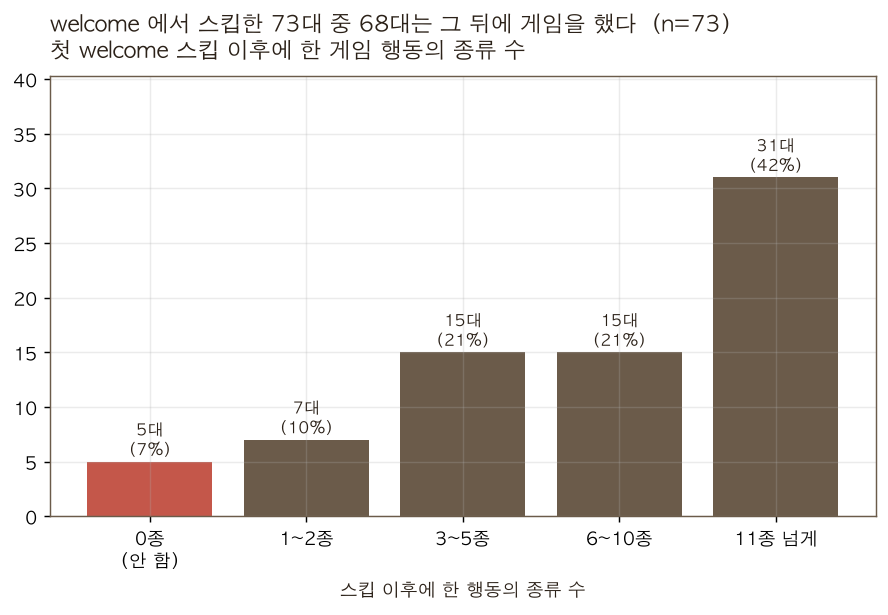

In [7]:
bins   = [-1, 0, 2, 5, 10, 10**9]
labels = ["0종\n(안 함)", "1~2종", "3~5종", "6~10종", "11종 넘게"]
g = pd.cut(skip73.kinds_after, bins=bins, labels=labels).value_counts().reindex(labels)

n = len(skip73)
fig, ax = R.new("welcome 에서 스킵한 73대 중 68대는 그 뒤에 게임을 했다", n=n,
                sub="첫 welcome 스킵 이후에 한 게임 행동의 종류 수",
                figsize=(8.2, 4.4))
ax.bar(labels, g.values, color=[R.PALETTE[0]] + [R.MUTED] * (len(labels) - 1))
ax.set_xlabel("스킵 이후에 한 행동의 종류 수")
for i, v in enumerate(g.values):
    ax.text(i, v + 0.6, f"{v}대\n({v/n:.0%})", ha="center", fontsize=9, color=R.INK)
ax.set_ylim(0, g.max() * 1.3)
R.show(R.save(fig, ax, "g_skip73_after"))

### 읽은 것 — 그리고 정정

68대(93%)가 스킵 뒤에도 게임을 했고, 42%는 11종 넘게 했다. **게임을 제일 많이 한 사람들이다.**

더 이상한 건 이쪽이다.

- 73대 중 **66대(90%)가 스킵하기 전에 이미** 게임을 하고 있었다
- 스킵 횟수 중앙값 3회, **최대 98회**

`tutorial_skip{at:'welcome'}` 565건은 "튜토리얼 거부"가 아니라
**환영 화면이 반복해서 뜨고 그때마다 닫는** 기록에 가깝다. 왜 반복되는지는 다음 절.

## 3. 왜 반복해서 뜨나 — 게스트 uid 회전

스킵 직전 이벤트를 세면 `login` 뒤 0초 간격이 268건(40대)이다.
`login` 은 페이지 로드 때 자동으로 찍히므로, **로드할 때마다 환영 모달이 뜨고 있다**는 뜻이다.

코드에 원인이 그대로 적혀 있다.

```js
// js/supabase-client.js:128
// ── 게스트로 플레이 (매번 새 익명계정 → 휘발성, 재방문 시 새 마을) ──
    // 혹시 남아있는 익명 세션이 있으면 정리 → 항상 새 게스트로 시작(A안)
    const { data: cur } = await supabase.auth.getSession();
    if (cur?.session && isAnon(cur.session)) await supabase.auth.signOut();
    const { data, error } = await supabase.auth.signInAnonymously();
```

`persistSession: true` 가 켜져 있어도 소용없다. 남은 익명 세션을 **일부러 로그아웃**시킨다.
세이브는 옛 uid 에 남지만 새 uid 로는 못 찾는다. **버그가 아니라 사양이다.**

In [8]:
key = bq.read_sql("""
SELECT
  (SELECT COUNT(DISTINCT user_id)   FROM `calm-forest.calm_forest_raw.game_logs`)  AS uids_with_logs,
  (SELECT COUNT(DISTINCT user_id)   FROM `calm-forest.calm_forest_raw.game_saves`) AS uids_with_save,
  (SELECT COUNT(DISTINCT client_id) FROM `calm-forest.calm_forest_raw.game_logs`)  AS stable_devices
""")
print(key.to_string(index=False))
print(f"\n기기당 uid {key.uids_with_logs[0]/key.stable_devices[0]:.2f}개")

size = bq.read_sql("""
SELECT COUNT(*) AS saves,
       ROUND(AVG(LENGTH(state))/1024, 1)   AS avg_kb,
       ROUND(SUM(LENGTH(state))/1048576, 2) AS total_mb,
       COUNTIF(JSON_VALUE(state, '$.character')    IS NOT NULL
           AND JSON_VALUE(state, '$.tutorialSeen') = 'true')  AS char_and_seen
FROM `calm-forest.calm_forest_raw.game_saves`
""")
print("\n" + size.to_string(index=False))

 uids_with_logs  uids_with_save  stable_devices
            669             210             205

기기당 uid 3.26개



 saves  avg_kb  total_mb  char_and_seen
   210     2.5       0.5            107


### 읽은 것

기기 205대가 uid 를 **667개** 만들었다(기기당 3.25개). 세이브가 붙은 uid 는 212개뿐이다.

저장 자체는 정상이다 — 캐릭터를 고른 세이브 117건 중 110건에 `tutorialSeen: true` 가 제대로 들어 있다.
문제는 **다음 방문에 그 세이브를 찾을 키가 없다**는 것.

**용량은 문제가 아니다.** 세이브 1건 평균 2.5KB, 212건 전부 합쳐 0.51MB.
게스트를 만 명 받아도 25MB다. 익명 계정을 7일마다 지우는 이유가 용량이라면 근거가 없다.

## 4. 대다수가 게스트다 — 그래서 세이브 기록으로는 못 본다

앞 절에서 `game_saves` 212건을 분모로 "110/117이 정상"이라고 읽었는데, 그건 살아남은 소수만 본 것이다.
전체가 어떻게 갈리는지 먼저 봐야 한다.

In [9]:
seg = bq.read_sql(f"""
WITH d AS (SELECT DISTINCT user_pseudo_id AS device FROM {GA4}),
m AS (
  SELECT user_pseudo_id AS device,
         LOGICAL_OR((SELECT value.string_value FROM UNNEST(event_params)
                     WHERE key='method') = 'google')    AS g,
         LOGICAL_OR((SELECT value.string_value FROM UNNEST(event_params)
                     WHERE key='method') = 'anonymous') AS a
  FROM {GA4} WHERE event_name='login' GROUP BY 1
)
SELECT CASE WHEN m.device IS NULL THEN '로그인 이벤트 없음'
            WHEN m.g THEN '구글 로그인'
            WHEN m.a THEN '게스트(익명)만'
            ELSE '기타(offline)' END AS grp,
       COUNT(*) AS devices,
       ROUND(100*COUNT(*)/SUM(COUNT(*)) OVER (), 1) AS pct
FROM d LEFT JOIN m USING (device)
GROUP BY 1 ORDER BY devices DESC
""")
print(seg.to_string(index=False))

        grp  devices  pct
 로그인 이벤트 없음      146 58.9
   게스트(익명)만       77 31.0
     구글 로그인       20  8.1
기타(offline)        5  2.0


### 읽은 것

**구글 로그인이 20대(8.2%)뿐이다.** `game_saves` 를 아무리 파도 전체의 8% 이야기이고,
나머지 92%는 세이브가 휘발이거나 아예 안 생긴다. 생존편향이다.

그리고 이게 앞 절의 결론도 바꾼다. 게스트에게 세이브 유실은 **고칠 버그가 아니라 기획 판단**이다.
게스트는 체험판이고, 안 남는 게 정상이라면 휘발 설계는 전제로 두고 그 안에서 방법을 찾아야 한다.

## 5. 게스트는 한 세션에 얼마나 하나

"체험판이 로그인하고 싶어질 만큼의 값을 주는가"를 재려면 먼저 얼마나 쌓이는지 봐야 한다.

순수 게스트(익명 로그인은 했고 구글은 한 번도 안 한 기기) 77대로 한정한다.
구글로 넘어간 20대는 게스트 시절과 로그인 이후가 섞여서 뺐다.

In [10]:
gs = bq.read_sql(f"""
WITH ev AS (
  SELECT user_pseudo_id AS device,
         (SELECT value.int_value FROM UNNEST(event_params) WHERE key='ga_session_id') AS sid,
         event_name, TIMESTAMP_MICROS(event_timestamp) AS ts,
         (SELECT value.int_value FROM UNNEST(event_params)
          WHERE key='engagement_time_msec') AS eng_ms
  FROM {GA4}
),
guests AS (
  SELECT user_pseudo_id AS device FROM {GA4}
  WHERE event_name='login' GROUP BY 1
  HAVING LOGICAL_OR((SELECT value.string_value FROM UNNEST(event_params)
                     WHERE key='method') = 'anonymous')
     AND NOT LOGICAL_OR((SELECT value.string_value FROM UNNEST(event_params)
                         WHERE key='method') = 'google')
),
PLAY AS (SELECT device, sid, event_name FROM ev WHERE event_name NOT IN ({EXCLUDE}))
SELECT e.device, e.sid,
       (SELECT COUNT(*)                    FROM PLAY p WHERE p.device=e.device AND p.sid=e.sid) AS acts,
       (SELECT COUNT(DISTINCT p.event_name) FROM PLAY p WHERE p.device=e.device AND p.sid=e.sid) AS kinds,
       (SELECT COUNTIF(p.event_name='dex_discover')
                                            FROM PLAY p WHERE p.device=e.device AND p.sid=e.sid) AS dex,
       TIMESTAMP_DIFF(MAX(e.ts), MIN(e.ts), SECOND) AS dur_sec,
       ROUND(SUM(e.eng_ms)/1000, 1)                 AS engaged_sec
FROM ev e JOIN guests USING (device)
GROUP BY 1, 2
""")

print(f"게스트 {gs.device.nunique()}대 · 세션 {len(gs)}개 "
      f"· 기기당 세션 중앙값 {gs.groupby('device').size().median():.1f}")
print()
for c in ["acts", "kinds", "dex", "dur_sec", "engaged_sec"]:
    q = gs[c].describe(percentiles=[.5, .75, .9])
    print(f"{c:12s} 중앙값 {q['50%']:>7.1f} | 75% {q['75%']:>7.1f} | 90% {q['90%']:>8.1f}")
print(f"\n도감 0개인 세션 {int((gs.dex==0).sum())}/{len(gs)} ({(gs.dex==0).mean():.0%})")
print(f"행동 0인 세션 {int((gs.acts==0).sum())}/{len(gs)} ({(gs.acts==0).mean():.0%})")

게스트 77대 · 세션 191개 · 기기당 세션 중앙값 1.0

acts         중앙값    11.0 | 75%    28.0 | 90%     73.0
kinds        중앙값     6.0 | 75%    11.0 | 90%     16.0
dex          중앙값     1.0 | 75%     2.0 | 90%      6.0
dur_sec      중앙값   188.0 | 75%  1020.5 | 90%   2508.0
engaged_sec  중앙값    44.0 | 75%   129.8 | 90%    223.2

도감 0개인 세션 89/191 (47%)
행동 0인 세션 37/191 (19%)


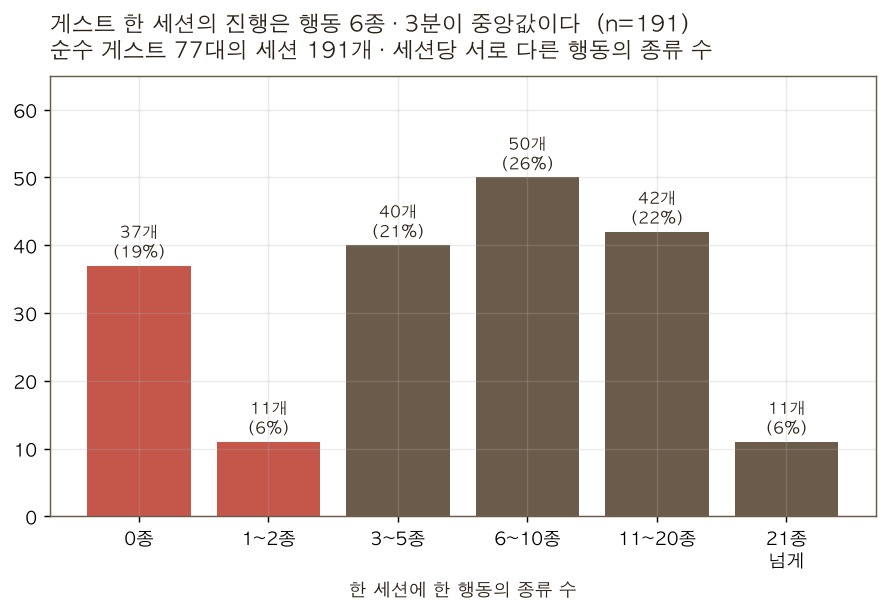

In [11]:
bins   = [-1, 0, 2, 5, 10, 20, 10**9]
labels = ["0종", "1~2종", "3~5종", "6~10종", "11~20종", "21종\n넘게"]
g = pd.cut(gs.kinds, bins=bins, labels=labels).value_counts().reindex(labels)

n = len(gs)
fig, ax = R.new("게스트 한 세션의 진행은 행동 6종 · 3분이 중앙값이다", n=n,
                sub="순수 게스트 77대의 세션 191개 · 세션당 서로 다른 행동의 종류 수",
                figsize=(8.2, 4.4))
ax.bar(labels, g.values, color=[R.PALETTE[0]] * 2 + [R.MUTED] * 4)
ax.set_xlabel("한 세션에 한 행동의 종류 수")
for i, v in enumerate(g.values):
    ax.text(i, v + 1.2, f"{v}개\n({v/n:.0%})", ha="center", fontsize=9, color=R.INK)
ax.set_ylim(0, g.max() * 1.3)
R.show(R.save(fig, ax, "g_guest_progress"))

### 읽은 것

**기기당 세션 중앙값 1.0** — 대부분 한 번 오고 끝난다.

한 세션에 행동 11회·6종·체류 188초. 그중 실제로 화면을 본 건 **44초**다.
분포는 양극이다. 25%는 2종 이하로 끝나고, 28%는 11종 넘게 한다. 가운데가 얇다.

전환 논의에 직결되는 건 이 숫자다.

- **도감 발견 중앙값 1개**
- **세션 191개 중 89개(47%)가 도감을 하나도 못 채운다**

도감 배너 문구가 "로그인하면 보존됩니다"인데, 절반은 **보존할 게 0개**인 상태로 그 배너를 본다.

## 6. 전환한 사람은 게스트를 거쳤나

"게스트가 쌓은 걸 아까워서 로그인한다"가 실제로 일어나는지 본다.
전환한 기기의 **첫 구글 로그인 이전** 세션만 게스트 시절로 잡고, 기기별 누적으로 비교했다.

In [12]:
conv = bq.read_sql(f"""
WITH ev AS (
  SELECT user_pseudo_id AS device,
         (SELECT value.int_value FROM UNNEST(event_params) WHERE key='ga_session_id') AS sid,
         event_name, TIMESTAMP_MICROS(event_timestamp) AS ts,
         (SELECT value.string_value FROM UNNEST(event_params) WHERE key='method') AS method
  FROM {GA4}
),
c AS (
  SELECT device,
         MIN(IF(event_name='login' AND method='google', ts, NULL)) AS first_google,
         LOGICAL_OR(event_name='login' AND method='anonymous')     AS ever_anon
  FROM ev GROUP BY device
),
plays AS (SELECT * FROM ev WHERE event_name NOT IN ({EXCLUDE}))
SELECT c.device,
       c.first_google IS NOT NULL AS converted,
       COUNTIF(c.first_google IS NULL OR p.ts < c.first_google) AS acts,
       COUNT(DISTINCT IF(c.first_google IS NULL OR p.ts < c.first_google, p.event_name, NULL)) AS kinds,
       COUNTIF(p.event_name='dex_discover'
               AND (c.first_google IS NULL OR p.ts < c.first_google)) AS dex,
       COUNT(DISTINCT IF(c.first_google IS NULL OR p.ts < c.first_google, p.sid, NULL)) AS sessions
FROM c LEFT JOIN plays p ON p.device = c.device
WHERE c.ever_anon OR c.first_google IS NOT NULL   -- 로그인 화면까지 온 기기만
GROUP BY c.device, c.first_google
""")

imm  = int(((conv.converted) & (conv.sessions == 0)).sum())
via  = int(((conv.converted) & (conv.sessions >  0)).sum())
none = int((~conv.converted).sum())
print(f"즉시 구글 {imm} · 게스트 거쳐 전환 {via} · 게스트만 {none}")
print("\n게스트 거쳐 전환한 기기의 게스트 시절 누적:")
print(conv[(conv.converted) & (conv.sessions > 0)][["acts","kinds","dex","sessions"]]
      .sort_values("kinds", ascending=False).to_string(index=False))

즉시 구글 15 · 게스트 거쳐 전환 5 · 게스트만 77

게스트 거쳐 전환한 기기의 게스트 시절 누적:
 acts  kinds  dex  sessions
  241     34   25        12
   89     16    8         1
   43      8    0         1
   32      7    0         1
    6      4    0         1


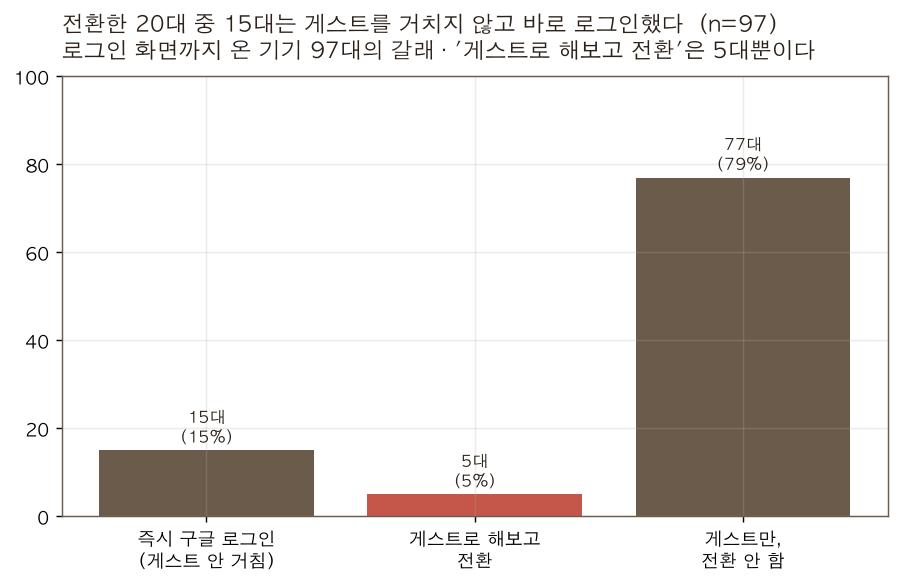

In [13]:
labels = ["즉시 구글 로그인\n(게스트 안 거침)", "게스트로 해보고\n전환", "게스트만,\n전환 안 함"]
vals   = [imm, via, none]
n = sum(vals)

fig, ax = R.new("전환한 20대 중 15대는 게스트를 거치지 않고 바로 로그인했다", n=n,
                sub="로그인 화면까지 온 기기 97대의 갈래 · '게스트로 해보고 전환'은 5대뿐이다",
                figsize=(8.2, 4.4))
# 우리가 키우려는 경로가 가운데인데 거기가 제일 얇다
ax.bar(labels, vals, color=[R.MUTED, R.PALETTE[0], R.MUTED])
for i, v in enumerate(vals):
    ax.text(i, v + 1.8, f"{v}대\n({v/n:.0%})", ha="center", fontsize=9, color=R.INK)
ax.set_ylim(0, max(vals) * 1.3)
R.show(R.save(fig, ax, "g_conversion_path"))

### 읽은 것

**"게스트로 해보고 전환"이 5건뿐이다.** 그 경로가 안 통한다는 증거가 아니라,
**그 경로로 들어온 사람이 거의 없다**는 사실이다. 5건으로는 통하는지 자체를 못 본다.

중앙값으로는 전환자가 오히려 덜 진행했다(종류 8종 vs 미전환 11종, 도감 0개 vs 2개).
**n=5라 방향을 말할 수 없다.**

⚠️ "게스트 시절 0"은 정의상 그렇게 나온다. 처음부터 구글을 누르면 `login{method:anonymous}` 가
안 찍히니 게스트 이력이 없다. 다만 그 15대가 게스트를 건너뛰었다는 사실 자체는 맞다.

## 7. 로그인 넛지는 작동하나

발화 조건은 코드에 셋이다.

```js
// js/game.js:745 — 도감이 정확히 5종째·12종째가 되는 순간
} else if (total === 5 || total === 12) {
  ui.loginNudge?.('dex' + total);
}

// index.html:2956 / 2990 — 사진 클라우드 저장, 사진첩 열기
if (isGuestNow()) { ui.loginNudge('album'); return; }
```

⚠️ 주석은 "3·7종"이라고 적혀 있는데 코드는 **5·12종**이다. 주석이 낡았다.

In [14]:
nudge = bq.read_sql(f"""
SELECT event_name,
       (SELECT COALESCE(value.string_value, CAST(value.int_value AS STRING))
        FROM UNNEST(event_params) WHERE key IN ('trigger','from')) AS src,
       COUNT(*) AS events, COUNT(DISTINCT user_pseudo_id) AS devices
FROM {GA4}
WHERE event_name IN ('login_nudge','login_nudge_click')
GROUP BY 1,2 ORDER BY 1, 3 DESC
""")
print(nudge.to_string(index=False))
print("\n※ login_nudge_click 과 trigger='album' 은 행 자체가 없다 = 0건")

reach = bq.read_sql(f"""
WITH g AS (
  SELECT user_pseudo_id AS device FROM {GA4}
  WHERE event_name='login' GROUP BY 1
  HAVING LOGICAL_OR((SELECT value.string_value FROM UNNEST(event_params)
                     WHERE key='method') = 'anonymous')
     AND NOT LOGICAL_OR((SELECT value.string_value FROM UNNEST(event_params)
                         WHERE key='method') = 'google')),
d AS (SELECT user_pseudo_id AS device, COUNT(*) AS dex FROM {GA4}
      WHERE event_name='dex_discover' GROUP BY 1)
SELECT COUNT(*) AS guest_devices,
       COUNTIF(COALESCE(d.dex,0) >= 5)  AS reached_5,
       COUNTIF(COALESCE(d.dex,0) >= 12) AS reached_12
FROM g LEFT JOIN d USING (device)
""")
print("\n게스트의 누적 도감 도달:")
print(reach.to_string(index=False))

 event_name   src  events  devices
login_nudge  dex5      16       10
login_nudge dex12       3        3

※ login_nudge_click 과 trigger='album' 은 행 자체가 없다 = 0건



게스트의 누적 도감 도달:
 guest_devices  reached_5  reached_12
            77         25          12


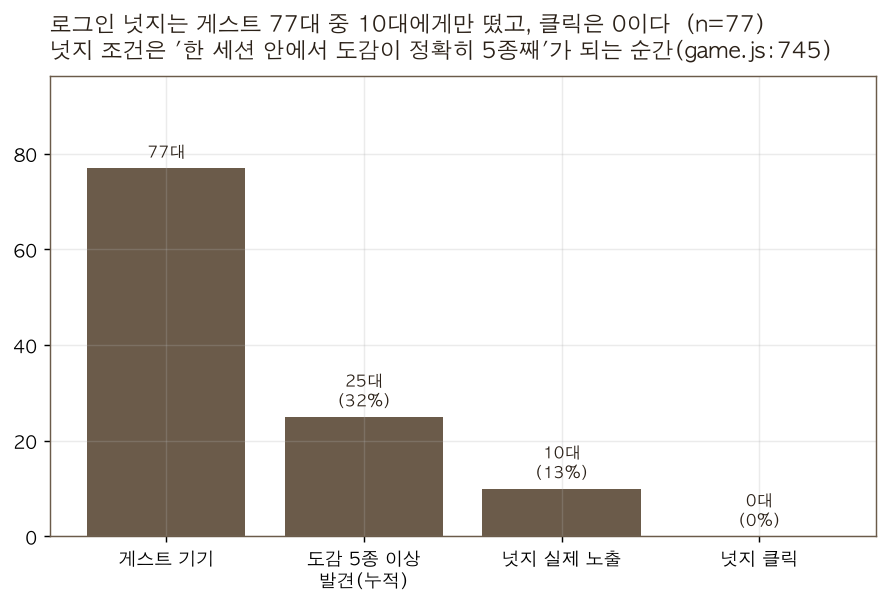

In [15]:
steps = ["게스트 기기", "도감 5종 이상\n발견(누적)", "넛지 실제 노출", "넛지 클릭"]
vals  = [77, 25, 10, 0]
n = vals[0]

fig, ax = R.new("로그인 넛지는 게스트 77대 중 10대에게만 떴고, 클릭은 0이다", n=n,
                sub="넛지 조건은 '한 세션 안에서 도감이 정확히 5종째'가 되는 순간(game.js:745)",
                figsize=(8.2, 4.6))
ax.bar(steps, vals, color=[R.MUTED] * 3 + [R.PALETTE[0]])
for i, v in enumerate(vals):
    ax.text(i, v + 2.2, f"{v}대" + (f"\n({v/n:.0%})" if i else ""),
            ha="center", fontsize=9, color=R.INK)
ax.set_ylim(0, n * 1.25)
R.show(R.save(fig, ax, "g_nudge_funnel"))

### 읽은 것

노출 19건(dex5 16건·10대, dex12 3건·3대), **클릭 0건**. 사진첩 넛지는 한 번도 안 떴다.

도감 5종 이상 발견한 게스트가 **25대인데 넛지는 10대에게만** 떴다.
조건이 `total === 5` 정확히 일치인데, 게스트는 매 세션 도감이 초기화된다.
3종 모으고 나갔다가 다시 와서 3종을 더 모으면 누적 6종이지만 **한 세션 안에서 5종째를 밟은 적이 없다.**
휘발 설계가 넛지 임계값을 사실상 도달 불가로 만들고 있다.

⚠️ **클릭 0건이 "문구가 나쁘다"는 뜻은 아니다.** 노출이 19건뿐이라, 전환율이 10%여도 0건이 자주 나온다.

## 8. 재방문한 게스트는 누구인가

게스트는 재방문할 때마다 마을이 지워진다. 그런데도 다시 온 사람이 있다면,
"게스트 리텐션"을 이야기할 때 가장 가까운 표본이다.

'다시 왔다'는 **다른 날에 또 접속**한 것으로 잡는다.
`ga_session_id` 는 30분 무활동으로도 끊겨서, 같은 날 두 세션이 재방문으로 잡히면 안 된다.

In [16]:
ret = bq.read_sql(f"""
WITH ev AS (
  SELECT user_pseudo_id AS device, event_name,
         DATE(TIMESTAMP_MICROS(event_timestamp), 'Asia/Seoul') AS d
  FROM {GA4}
),
guests AS (
  SELECT user_pseudo_id AS device FROM {GA4}
  WHERE event_name='login' GROUP BY 1
  HAVING LOGICAL_OR((SELECT value.string_value FROM UNNEST(event_params)
                     WHERE key='method') = 'anonymous')
     AND NOT LOGICAL_OR((SELECT value.string_value FROM UNNEST(event_params)
                         WHERE key='method') = 'google')
),
plays AS (SELECT * FROM ev WHERE event_name NOT IN ({EXCLUDE})),
fd AS (SELECT device, MIN(d) AS d0, MAX(d) AS dlast FROM ev GROUP BY 1)
SELECT g.device,
       (SELECT COUNT(DISTINCT e.d) FROM ev e WHERE e.device = g.device) AS days,
       DATE_DIFF(f.dlast, f.d0, DAY)                                    AS span_days,
       (SELECT COUNT(*) FROM plays p WHERE p.device=g.device AND p.d=f.d0) AS acts_d0,
       (SELECT COUNT(DISTINCT p.event_name) FROM plays p
          WHERE p.device=g.device AND p.d=f.d0)                         AS kinds_d0,
       (SELECT COUNTIF(p.event_name='dex_discover') FROM plays p
          WHERE p.device=g.device AND p.d=f.d0)                         AS dex_d0,
       (SELECT COUNT(*) FROM plays p WHERE p.device=g.device)           AS acts_all
FROM guests g JOIN fd f USING (device)
""")
ret["ret"] = ret.days >= 2
print(f"게스트 {len(ret)}대 · 재방문(2일 이상) {int(ret.ret.sum())}대 ({ret.ret.mean():.0%})")
vc = ret.days.value_counts().sort_index()
# to_dict() 를 그대로 찍으면 np.int64(1) 같은 게 새어 나온다
print("방문 일수:", " · ".join(f"{int(k)}일 {int(v)}대" for k, v in vc.items()))
print()
for c, nm in [("acts_d0","첫날 행동 수"), ("kinds_d0","첫날 종류"), ("dex_d0","첫날 도감")]:
    a, b = ret[ret.ret][c], ret[~ret.ret][c]
    print(f"{nm:9s} 재방문 {a.median():>5.1f} (n={len(a)})  vs  1회성 {b.median():>5.1f} (n={len(b)})")
print()
print("재방문 기기 원자료(첫날 기준):")
print(ret[ret.ret][["days","span_days","acts_d0","kinds_d0","dex_d0","acts_all"]]
      .sort_values("days", ascending=False).to_string(index=False))

게스트 77대 · 재방문(2일 이상) 12대 (16%)
방문 일수: 1일 65대 · 2일 6대 · 3일 1대 · 4일 3대 · 6일 1대 · 13일 1대

첫날 행동 수   재방문  21.5 (n=12)  vs  1회성  21.0 (n=65)
첫날 종류     재방문   8.5 (n=12)  vs  1회성  10.0 (n=65)
첫날 도감     재방문   0.0 (n=12)  vs  1회성   2.0 (n=65)

재방문 기기 원자료(첫날 기준):
 days  span_days  acts_d0  kinds_d0  dex_d0  acts_all
   13         25       13         9       0       805
    6          5       15         7       0        87
    4          3       28         8       3        91
    4          4        0         0       0        36
    4          3       30        13       3       228
    3          2       29         9       0        39
    2          1       13         7       2       107
    2          1        6         2       0        17
    2         12        8         4       0        16
    2          1       59        10       0       204
    2          1       78        13      14        87
    2          6       51        12       0        53


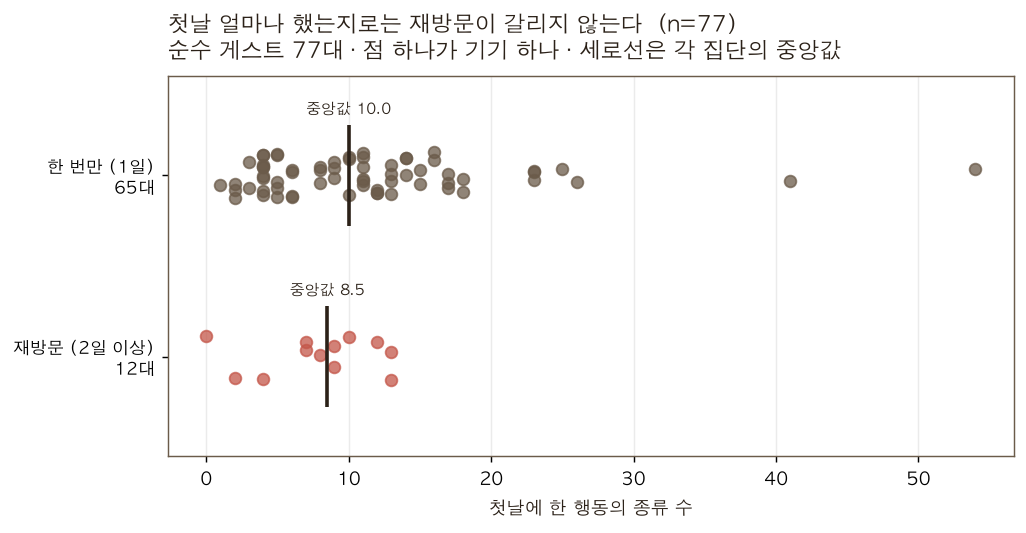

In [17]:
import numpy as np

# 두 집단을 점으로 흩뿌려 겹침을 그대로 보인다.
# 막대 + 중앙값만 그리면 n=12 인데 차이가 있는 것처럼 읽힌다.
rr, oo = ret[ret.ret], ret[~ret.ret]
n = len(ret)
fig, ax = R.new("첫날 얼마나 했는지로는 재방문이 갈리지 않는다", n=n,
                sub="순수 게스트 77대 · 점 하나가 기기 하나 · 세로선은 각 집단의 중앙값",
                figsize=(8.4, 3.8))
rng = np.random.default_rng(0)
groups = [("재방문 (2일 이상)", rr, R.PALETTE[0]), ("한 번만 (1일)", oo, R.MUTED)]
for i, (lab, sub, col) in enumerate(groups):
    y = i + rng.uniform(-0.13, 0.13, len(sub))
    ax.scatter(sub.kinds_d0, y, s=42, alpha=0.75, color=col, zorder=3)
    m = sub.kinds_d0.median()
    ax.vlines(m, i - 0.28, i + 0.28, color=R.INK, linewidth=2, zorder=4)
    ax.text(m, i + 0.34, f"중앙값 {m:.1f}", ha="center", fontsize=8.5, color=R.INK)
ax.set_yticks([0, 1])
ax.set_yticklabels([f"{lab}\n{len(sub)}대" for lab, sub, _ in groups], fontsize=9.5)
ax.set_ylim(-0.55, 1.55)
ax.set_xlabel("첫날에 한 행동의 종류 수")
ax.grid(axis="y", visible=False)
R.show(R.save(fig, ax, "g_returner_firstday", zero_base=False))

### 읽은 것

재방문은 **12대(16%)**. 그중 절반(6대)이 딱 이틀이고, 꾸준한 건 6일 1대·13일 1대뿐이다.

첫날 진행량은 재방문을 **가르지 못한다.**

| | 재방문 12대 | 1회성 65대 |
|---|---|---|
| 첫날 행동 수 | 21.5 | 21.0 |
| 첫날 행동 종류 | 8.5 | **10.0** |
| 첫날 도감 | 0.0 | **2.0** |

차트에서 재방문 12대가 1회성 분포 **안에** 완전히 들어가 있다. 별개 집단으로 안 보인다.
오히려 종류와 도감은 1회성 쪽이 높다.

**첫날 행동이 0인데 4일을 온 기기가 있다.** 첫날 진행량이 재방문 조건이 아니라는 걸
이 한 줄이 보여준다.

n=12 다. 중앙값 8.5 vs 10.0 은 아무 의미가 없다. "차이가 있다"고도 "없다"고도 못 하고,
정확히는 **가릴 힘이 없다.**

## 9. 재방문 12대는 어떤 활동을 했나

재방문은 며칠을 더 왔으니 활동이 많은 게 당연하다. 그래서 두 가지를 낸다 —
전 기간 집계와, 노출을 맞춘 **첫날 기준** 비교.

In [18]:
acts = bq.read_sql(f"""
WITH ev AS (
  SELECT user_pseudo_id AS device, event_name,
         DATE(TIMESTAMP_MICROS(event_timestamp), 'Asia/Seoul') AS d
  FROM {GA4}
),
guests AS (
  SELECT user_pseudo_id AS device FROM {GA4}
  WHERE event_name='login' GROUP BY 1
  HAVING LOGICAL_OR((SELECT value.string_value FROM UNNEST(event_params)
                     WHERE key='method') = 'anonymous')
     AND NOT LOGICAL_OR((SELECT value.string_value FROM UNNEST(event_params)
                         WHERE key='method') = 'google')
),
plays AS (SELECT * FROM ev WHERE event_name NOT IN ({EXCLUDE})),
fd AS (SELECT device, MIN(d) AS d0 FROM ev GROUP BY 1),
cls AS (
  SELECT g.device, f.d0,
         (SELECT COUNT(DISTINCT e.d) FROM ev e WHERE e.device=g.device) >= 2 AS ret
  FROM guests g JOIN fd f USING (device)
),
pd AS (SELECT DISTINCT p.device, p.event_name, p.d = c.d0 AS is_d0
       FROM plays p JOIN cls c USING (device))
SELECT pd.event_name,
       COUNT(DISTINCT IF(c.ret     AND pd.is_d0, pd.device, NULL)) AS ret_d0,
       COUNT(DISTINCT IF(NOT c.ret AND pd.is_d0, pd.device, NULL)) AS one_d0,
       COUNT(DISTINCT IF(c.ret, pd.device, NULL))                  AS ret_all
FROM pd JOIN cls c USING (device)
GROUP BY 1
""")
acts["ret_d0_pct"] = acts.ret_d0 / 12
acts["one_d0_pct"] = acts.one_d0 / 65
acts["diff"] = acts.ret_d0_pct - acts.one_d0_pct

print("첫날 기준 비교 — 차이가 큰 순 (분모 12 vs 65)")
sel = acts[(acts.ret_d0 >= 3) | (acts.one_d0 >= 20)]
print(sel.reindex(sel["diff"].abs().sort_values(ascending=False).index)
        .head(10)[["event_name","ret_d0","one_d0","ret_d0_pct","one_d0_pct","diff"]]
        .to_string(index=False, float_format=lambda x: f"{x:.2f}"))

첫날 기준 비교 — 차이가 큰 순 (분모 12 vs 65)
         event_name  ret_d0  one_d0  ret_d0_pct  one_d0_pct  diff
       dex_discover       4      49        0.33        0.75 -0.42
        daily_bonus       5      53        0.42        0.82 -0.40
        intro_start       2      30        0.17        0.46 -0.29
       nickname_set       2      30        0.17        0.46 -0.29
story_chapter_start       2      30        0.17        0.46 -0.29
   character_select       7      56        0.58        0.86 -0.28
         enter_farm       4       5        0.33        0.08  0.26
          exit_farm       4       5        0.33        0.08  0.26
         intro_skip       1      22        0.08        0.34 -0.26
      tutorial_skip       9      54        0.75        0.83 -0.08


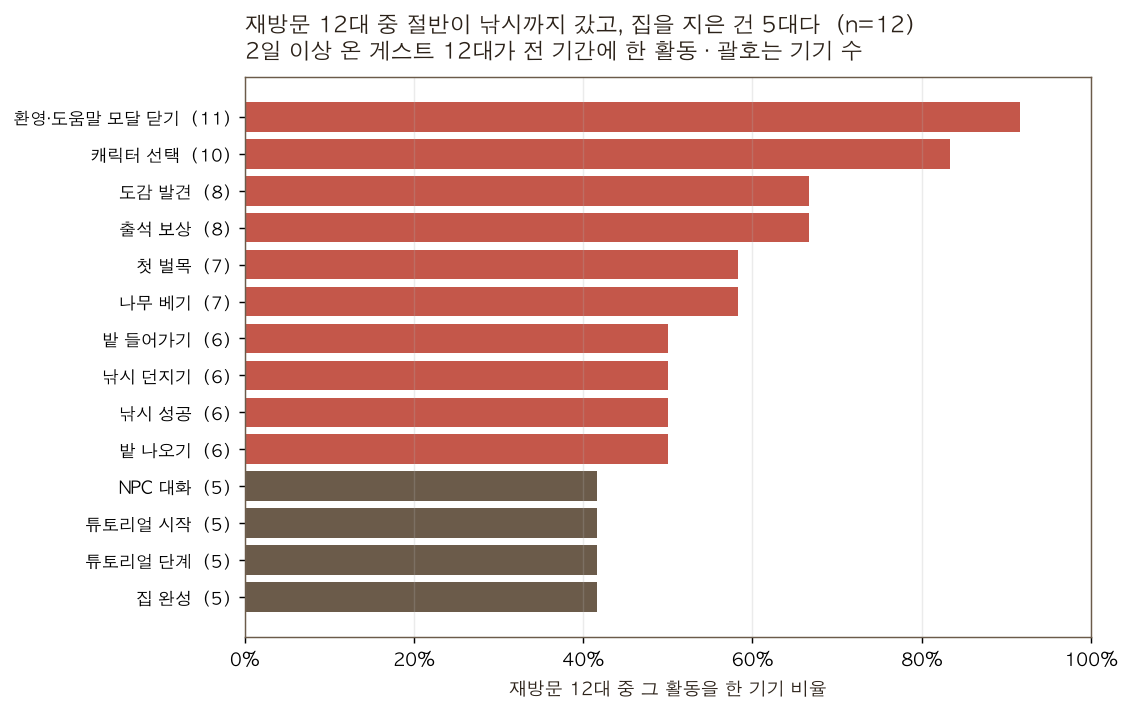

In [19]:
KO = {"tutorial_skip":"환영·도움말 모달 닫기","character_select":"캐릭터 선택",
      "daily_bonus":"출석 보상","dex_discover":"도감 발견","first_chop":"첫 벌목",
      "chop_tree":"나무 베기","fishing_cast":"낚시 던지기","fishing_catch":"낚시 성공",
      "enter_farm":"밭 들어가기","exit_farm":"밭 나오기","house_complete":"집 완성",
      "npc_talk":"NPC 대화","tutorial_start":"튜토리얼 시작","tutorial_step":"튜토리얼 단계"}

d = acts.nlargest(14, "ret_all").copy()
d["label"] = d.event_name.map(lambda s: KO.get(s, s))
n = 12
fig, ax = R.new("재방문 12대 중 절반이 낚시까지 갔고, 집을 지은 건 5대다", n=n,
                sub="2일 이상 온 게스트 12대가 전 기간에 한 활동 · 괄호는 기기 수",
                figsize=(8.4, 5.6))
y = range(len(d))
ax.barh(list(y), d.ret_all / n,
        color=[R.PALETTE[0] if v >= 6 else R.MUTED for v in d.ret_all])
ax.set_yticks(list(y))
ax.set_yticklabels([f"{l}  ({v})" for l, v in zip(d.label, d.ret_all)], fontsize=9.5)
ax.invert_yaxis()
ax.set_xlabel("재방문 12대 중 그 활동을 한 기기 비율")
from matplotlib.ticker import FuncFormatter
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_xlim(0, 1.0)
ax.grid(axis="y", visible=False)
R.show(R.save(fig, ax, "g_returner_acts", zero_base=False))

### 읽은 것

전 기간으로 보면 캐릭터 선택 10대 → 출석·도감 8대 → 벌목 7대 → 낚시·밭 6대 → 집 완성 5대.
1위인 `환영·도움말 모달 닫기` 11대는 활동이 아니라 2~3절에서 본 모달 반복 문제다.
순위에서 빼고 읽어야 한다.

**첫날로 노출을 맞추면 방향이 뒤집힌다.**

| 활동 | 재방문(12대) | 1회성(65대) | 차이 |
|---|---|---|---|
| 밭 들어가기 | 33% (4) | 8% (5) | **+26%p** |
| 캐릭터 선택 | 58% (7) | 86% (56) | −28%p |
| 출석 보상 | 42% (5) | 82% (53) | −40%p |
| 도감 발견 | 33% (4) | 75% (49) | −42%p |

재방문자가 첫날에 **오히려 덜 했다.** 1회성 65대에게는 첫날이 곧 전부라 그 하루에 온보딩을
다 밟고 끝냈고, 재방문 12대는 첫날을 가볍게 보고 나갔다가 다시 왔다.

**첫날에 많이 시키는 게 재방문으로 이어진다는 근거가 이 데이터에는 없다.** 오히려 반대 방향이다.

유일하게 높은 밭 출입도 **4대 vs 5대**다. 인과 방향도 못 가린다 —
밭에 간 사람이 다시 온 게 아니라, 다시 올 사람이 밭까지 갔을 수 있다.
그리고 "덜 하는 게 좋다"는 뜻도 아니다. 가볍게 만들면 재방문이 는다는 근거가 아니다.

## 10. 게스트는 어느 행동까지 하고 멈추나

여기서 하고 싶었던 건 "유저가 A 하다가 B 하다가 이탈"을 순서대로 잇는 그림이었다.
**그건 이 데이터로 못 그린다.** 먼저 그 이유부터 확인한다.

In [20]:
ties = bq.read_sql(f"""
WITH ev AS (
  SELECT user_pseudo_id AS device, event_name, TIMESTAMP_MICROS(event_timestamp) AS ts
  FROM {GA4}
),
guests AS (
  SELECT user_pseudo_id AS device FROM {GA4}
  WHERE event_name='login' GROUP BY 1
  HAVING LOGICAL_OR((SELECT value.string_value FROM UNNEST(event_params)
                     WHERE key='method') = 'anonymous')
     AND NOT LOGICAL_OR((SELECT value.string_value FROM UNNEST(event_params)
                         WHERE key='method') = 'google')
),
plays AS (SELECT e.* FROM ev e JOIN guests USING (device)
          WHERE e.event_name NOT IN ({EXCLUDE}) AND e.event_name NOT LIKE 'tutorial%'),
firsts AS (SELECT device, event_name, MIN(ts) AS t FROM plays GROUP BY 1, 2),
per AS (SELECT device, COUNT(*) AS acts, COUNT(DISTINCT t) AS distinct_ts
        FROM firsts GROUP BY 1)
SELECT COUNT(*)                  AS devices,
       COUNTIF(acts > distinct_ts) AS devices_with_ties,
       ROUND(AVG(acts), 1)       AS avg_acts,
       ROUND(AVG(distinct_ts), 1) AS avg_distinct_ts
FROM per
""")
print(ties.to_string(index=False))

 devices  devices_with_ties  avg_acts  avg_distinct_ts
      75                 71      11.5              6.7


### 순서를 알 수 없다

**기기 75대 중 71대(95%)** 가 서로 다른 활동의 첫 시각이 같다.
기기당 활동 종류는 평균 11.5개인데 **서로 다른 시각은 6.7개**뿐이다.
같은 JS 틱에서 발생한 이벤트에 GA4 가 같은 `event_timestamp` 를 주기 때문이다.

정렬에 타이브레이커를 넣으면 결과는 결정적이 되지만, 그건 **가나다순 부산물**이지 실제 순서가 아니다.
실제로 그렇게 그렸더니 첫 활동이 `도감` 49대로 쏠렸다 — 순서가 아니라 자모 순서였다.

이 문제는 [logger.js](../js/logger.js) 의 per-sample 타임스탬프 부재와 같은 뿌리다.
순서 분석을 하려면 **클라이언트가 증가하는 시퀀스 번호를 실어 보내야** 한다.

### 대신 순서를 우리가 정한다

퍼널은 단계 순서를 분석자가 정하므로 이 문제를 안 탄다.
게임이 의도한 진행 순서로 놓고, **앞 단계를 모두 마친 기기만** 다음 단계로 센다(그래야 진짜 퍼널이다).

In [21]:
fn = bq.read_sql(f"""
WITH guests AS (
  SELECT user_pseudo_id AS device FROM {GA4}
  WHERE event_name='login' GROUP BY 1
  HAVING LOGICAL_OR((SELECT value.string_value FROM UNNEST(event_params)
                     WHERE key='method') = 'anonymous')
     AND NOT LOGICAL_OR((SELECT value.string_value FROM UNNEST(event_params)
                         WHERE key='method') = 'google')
)
SELECT g.device,
  LOGICAL_OR(e.event_name='character_select')                AS s_char,
  LOGICAL_OR(e.event_name IN ('chop_tree','first_chop'))     AS s_chop,
  LOGICAL_OR(e.event_name IN ('plant_seed','water_crop'))    AS s_farm,
  LOGICAL_OR(e.event_name='harvest_crop')                    AS s_harv,
  LOGICAL_OR(e.event_name='shop_sell')                       AS s_sell
FROM guests g
LEFT JOIN {GA4} e ON e.user_pseudo_id = g.device
GROUP BY 1
""")

steps = [("s_char","캐릭터 선택"), ("s_chop","나무 베기"),
         ("s_farm","밭갈이·물주기"), ("s_harv","수확"), ("s_sell","판매 이후")]
labels, remain = ["게스트 진입"], [len(fn)]
ok = pd.Series(True, index=fn.index)
for c, lab in steps:
    ok = ok & fn[c].fillna(False)
    labels.append(lab); remain.append(int(ok.sum()))
churn = [remain[i] - remain[i+1] for i in range(len(remain)-1)]
print("남음:", dict(zip(labels, remain)))
print("단계별 이탈:", churn)

남음: {'게스트 진입': 77, '캐릭터 선택': 66, '나무 베기': 21, '밭갈이·물주기': 5, '수확': 5, '판매 이후': 1}
단계별 이탈: [11, 45, 16, 0, 4]


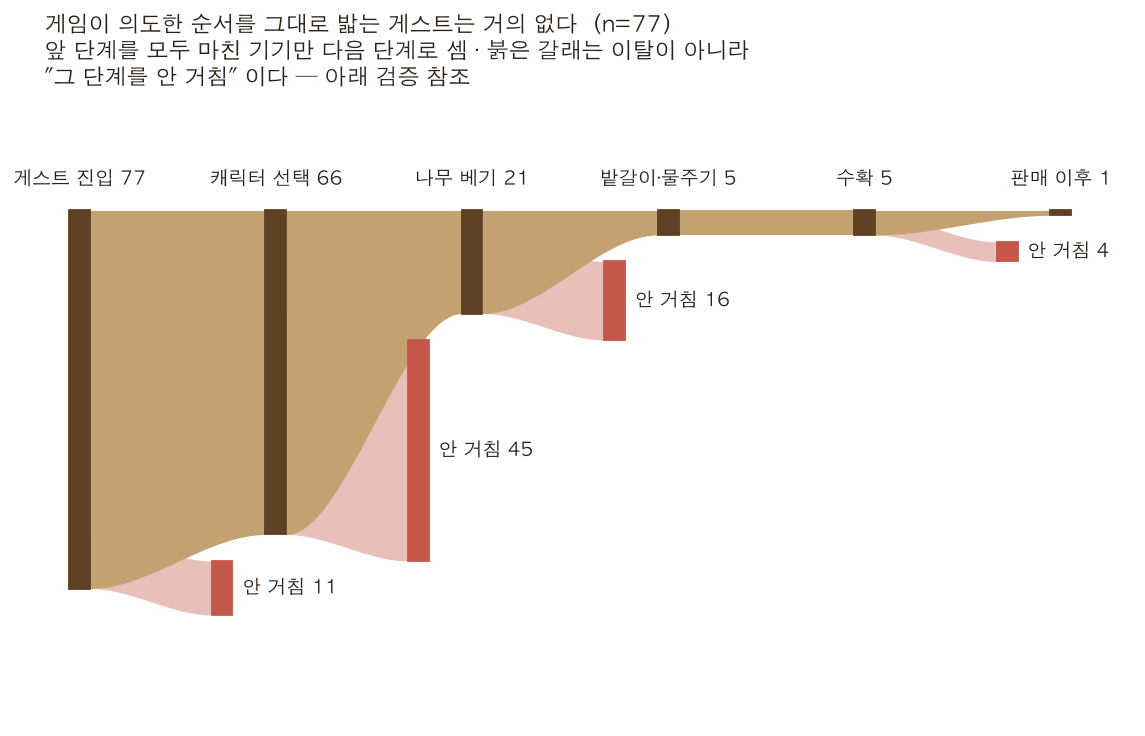

In [22]:
import numpy as np
import matplotlib.patches as mp

BAR  = R.RAMP[4]                    # 노드 — 곰 갈색 램프 최암부
FLOW = R.RAMP[0]                    # 본류 — 밝은 탄색
DROP = R.PALETTE[0]                 # 이탈 아님 — "이 단계를 안 거침" 블록
RIBB = R.tint(R.PALETTE[0], 0.62)   # 같은 색의 연한 톤

N = remain[0]
fig, ax = R.new("게임이 의도한 순서를 그대로 밟는 게스트는 거의 없다", n=N,
                sub="앞 단계를 모두 마친 기기만 다음 단계로 셈 · 붉은 갈래는 이탈이 아니라\n"
                    "\"그 단계를 안 거침\" 이다 — 아래 검증 참조",
                figsize=(10.8, 6.2))

def band(x0, x1, ya0, ya1, yb0, yb1, color, z):
    """양 끝 두께를 유지하며 잇는 리본. 두께가 곧 기기 수다."""
    t = np.linspace(0, 1, 140)
    s = 3*t**2 - 2*t**3
    ax.fill_between(x0 + (x1-x0)*t, ya0 + (ya1-ya0)*s, yb0 + (yb1-yb0)*s,
                    color=color, lw=0, zorder=z)

DX, W, BW = 1.6, 0.17, 0.17
OFF = 0.07 * N                      # 갈래 블록을 본류 바로 아래에 붙이는 간격

for i, (lab, v) in enumerate(zip(labels, remain)):
    x = i * DX
    ax.add_patch(mp.Rectangle((x, -v), W, max(v, 1.0), color=BAR, zorder=6))
    ax.text(x + W/2, 4, f"{lab} {v}", ha="center", va="bottom",
            fontsize=10.5, color=R.INK)

for i, c in enumerate(churn):
    x0 = i * DX + W
    band(x0, (i+1)*DX, 0, 0, -remain[i], -remain[i+1], FLOW, 4)   # 이어지는 흐름
    if not c:
        continue
    bx, top = x0 + DX*0.62, -remain[i+1] - OFF
    band(x0, bx, -remain[i+1], top, -remain[i], top - c, RIBB, 2)  # 안 거친 갈래
    ax.add_patch(mp.Rectangle((bx, top - c), BW, c, color=DROP, zorder=6))
    ax.text(bx + BW + 0.08, top - c/2, f"안 거침 {c}", va="center",
            fontsize=10.5, color=R.INK)

ax.set_xlim(-0.2, (len(remain)-1)*DX + W + 0.5)
ax.set_ylim(-N - OFF - 22, 22)
ax.axis("off")
R.show(R.save(fig, ax, "g_guest_funnel_sankey", zero_base=False))

### ⚠️ 이 그림을 "이탈" 로 읽으면 안 된다

위 퍼널은 **앞 단계를 모두 마친 기기만** 다음으로 세는 엄격 퍼널이다.
그래서 순서를 건너뛴 기기가 전부 "빠진 것" 으로 잡힌다.
처음엔 이걸 "병목은 벌목" 이라고 읽었는데, 그 45대를 열어보니 틀렸다.

In [23]:
# 캐릭터는 골랐지만 나무는 안 벤 45대가 그 뒤에 실제로 뭘 했는지
stuck = bq.read_sql(f"""
WITH guests AS (
  SELECT user_pseudo_id AS device FROM {GA4}
  WHERE event_name='login' GROUP BY 1
  HAVING LOGICAL_OR((SELECT value.string_value FROM UNNEST(event_params)
                     WHERE key='method') = 'anonymous')
     AND NOT LOGICAL_OR((SELECT value.string_value FROM UNNEST(event_params)
                         WHERE key='method') = 'google')
),
ev AS (SELECT user_pseudo_id AS device, event_name,
              TIMESTAMP_MICROS(event_timestamp) AS ts FROM {GA4}),
flags AS (
  SELECT g.device,
    LOGICAL_OR(e.event_name='character_select')             AS did_char,
    LOGICAL_OR(e.event_name IN ('chop_tree','first_chop'))  AS did_chop,
    MIN(IF(e.event_name='character_select', e.ts, NULL))    AS char_ts,
    MAX(e.ts)                                               AS last_ts
  FROM guests g LEFT JOIN ev e USING (device) GROUP BY 1
),
sel AS (SELECT * FROM flags WHERE did_char AND NOT did_chop)
SELECT
  COUNT(*) AS n,
  COUNTIF(kinds_after = 0)              AS did_nothing_after,
  COUNTIF(kinds_after BETWEEN 1 AND 2)  AS did_1_2,
  COUNTIF(kinds_after >= 3)             AS did_3plus,
  APPROX_QUANTILES(sec_after, 2)[OFFSET(1)] AS median_sec_after
FROM (
  SELECT s.device,
    COUNT(DISTINCT IF(e.ts > s.char_ts AND e.event_name NOT IN ({EXCLUDE})
                      AND e.event_name NOT LIKE 'tutorial%',
                      e.event_name, NULL))                  AS kinds_after,
    TIMESTAMP_DIFF(s.last_ts, s.char_ts, SECOND)            AS sec_after
  FROM sel s JOIN ev e USING (device)
  GROUP BY s.device, s.last_ts, s.char_ts
)
""")
print(stuck.to_string(index=False))
print(f"\n→ 45대 중 이탈은 {int(stuck.did_nothing_after[0])}대뿐. "
      f"나머지는 캐릭터 선택 후 중앙값 {int(stuck.median_sec_after[0])}초"
      f"({stuck.median_sec_after[0]/60:.0f}분) 를 더 놀았다.")

 n  did_nothing_after  did_1_2  did_3plus  median_sec_after
45                  4        7         34              1698

→ 45대 중 이탈은 4대뿐. 나머지는 캐릭터 선택 후 중앙값 1698초(28분) 를 더 놀았다.


### 읽은 것 — 병목이 아니었다

**45대 중 이탈은 4대뿐이다.** 34대(76%)가 캐릭터 선택 뒤에 3종 이상을 했고,
중앙값 **28분**을 더 놀았다. 그동안 한 것은 도감 발견 30대 · 출석 보상 25 ·
인트로 16 · 닉네임 13 · 이야기 12 · 구역 진입 10 · NPC 대화 9다.

**나무를 안 벴을 뿐, 떠난 게 아니다.** 벌목은 막힌 관문이 아니라 그 사람들이 안 가는 길이다.

처음엔 이 그림을 두고 "게스트는 나무 베기 앞에서 무너진다" 는 제목까지 달았다.
엄격 퍼널의 한계를 각주로 적어두긴 했지만, 실제로 재보니 **한계가 아니라 결론 자체를 뒤집는 크기**였다.
확인하지 않고 제목을 단 것이 잘못이다.

### 그래서 이 퍼널이 말해주는 것

"게임이 의도한 순서를 그대로 밟는 사람이 거의 없다" 는 것. 그 이상은 아니다.
어느 단계가 어렵다거나 어디서 떠난다는 말은 이 그림으로 할 수 없다.

### 이 그림으로 말할 수 없는 것

- **붉은 갈래는 이탈이 아니다.** "그 단계를 안 거침" 이다. 벌목 없이 낚시부터 한 게스트도 여기 들어간다.
- **단계 순서는 분석자가 정한 것**이다. 순서를 바꾸면 그림이 통째로 바뀐다.
- **판매 이후는 1대**다. 그 아래 구간의 비율은 읽으면 안 된다.
- 실제 이탈 지점을 보려면 순서를 강제하지 않는 도달률(§7 방식)이나
  `02_churn_where.ipynb` 의 마지막 활동 분석을 봐야 한다.

## 남는 것

### 이 노트북에서 내가 틀렸다가 고친 것

기록에서 지우지 않는다. 나중에 이 노트북을 읽는 사람이 같은 오답을 다시 집지 않게 하려는 것이다.

| 처음 읽은 것 | 실제 |
|---|---|
| welcome 스킵 73대 = 튜토리얼 거부 집단 | 게임을 가장 많이 한 집단(93%가 스킵 후 플레이) |
| 환영 모달 반복은 ❓도움말 버튼 탓 | 도움말도 같은 모달을 열지만, 주원인은 게스트 uid 회전 |
| 휘발 설계가 리텐션과 충돌한다 | 게스트=체험판은 의도된 사양. 전제로 둬야 한다 |
| `game_saves` 로 상태를 판단 가능 | 로그인 8%만 남는 생존편향 |
| `tutorial_complete` 를 믿을 수 없다 | 정상 작동한다. `max_step` 이 평생 최대값이라 다른 날 다른 판의 기록과 섞어 읽은 것 |
| 게스트 퍼널 "병목은 벌목" | 45대 중 41대가 이탈이 아니라 다른 길로 간 것. 28분을 더 놀았다 |

### 이 숫자로 말할 수 없는 것

- **배포 시점은 커밋 시점과 다르다.** 배포가 수동(`npx wrangler deploy`)이라 07-29 에
  6단계판과 11단계판 중 어느 게 언제부터 떠 있었는지 커밋 로그로는 확정 못 한다.
- **17단계판 완주 0대가 '너무 길다'는 뜻은 아니다.** 09-02 배포라 관측이 하루뿐이다.
- **`step` 인덱스가 시점마다 다른 내용을 가리킨다.** "2단계가 문제다" 같은 말은 못 한다.
- **`carve` 0건은 아직 판정 불가다.** 09-01 도입이라 관측이 하루뿐이다. 며칠 더 봐야 갈린다.
- **구글 로그인 기기 10대가 로그인 이후에도 104건 스킵했다.** 설명 못 한다.
- **141대(58%)가 로그인 화면조차 못 봤다.** 왜인지 모른다.
- **게스트 체류 188초 vs 시청 44초.** 나머지가 로딩인지 방치인지 안 갈린다.
- **`ga_session_id` 는 30분 무활동으로 끊긴다.** 한 방문이 두 세션으로 갈렸을 수 있다.
- **코인·집 진행은 GA4 에 없다.** 세이브에만 있는데 게스트 세이브는 휘발된다.
- **재방문 게스트가 12대뿐이다.** 첫날 지표로 갈리는지 자체를 가릴 힘이 없다.
- **관측 기간을 안 맞췄다.** 8월 말 첫 방문 기기는 다시 올 시간이 며칠뿐이라 1회성으로 잡힌다.
- **13일·805행동 기기가 개발자 본기기일 수 있다.** 확인 안 했다. 재방문 12대 중 1대라
  빼면 비율이 8%p씩 움직인다.
- **활동 순서를 알 수 없다.** 기기 95% 가 타임스탬프 동률이라 '무엇을 먼저 했나' 는 복원 불가다.
  순서 분석을 하려면 클라이언트가 증가하는 시퀀스 번호를 실어 보내야 한다.
- n 이 작다 — 튜토리얼 26대, 전환 경로 5대, 넛지 노출 19건, 재방문 12대. 어느 비율도 구간이 넓다.

### 고친 것 / 안 고친 것

| | 상태 |
|---|---|
| `tutorial_skip{at}` 를 `welcome` / `help` 로 분리 | **고침**(index.html 3곳). 과거 데이터는 소급 분리 불가 |
| 주석 "3·7종" vs 코드 5·12종 | 안 고침 |
| `js/config.js` 에 GA4 localhost 가드 없음 | 안 고침. 로컬로 index.html 을 열면 실계정이 오염된다 |